Import libraries & load data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data = pd.read_csv('Walmart_Sales.csv',
                   dtype={
                       'Store':np.int32, # Store number
                       'Date' :'category', # date
                       'Weekly_Sales':np.float64, # Represents weekly sales
                       'Holiday_Flag':np.int8, # 1 = Holiday week, 0 = Non-Holiday week 
                       'Temperature':np.float32, # Temperature
                       'Fuel_Price':np.float16, # Cost of fuel 
                       'CPI':np.float32, # Consumer Price Index
                       'Unemployment':np.float16 # Unemployment rate
                   })

In [19]:
data.head()

d:\ProgramData\anaconda3\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.310001,2.572266,211.096359,8.109375
1,1,12-02-2010,1641957.44,1,38.509998,2.548828,211.242172,8.109375
2,1,19-02-2010,1611968.17,0,39.930000,2.513672,211.289139,8.109375
3,1,26-02-2010,1409727.59,0,46.630001,2.560547,211.319641,8.109375
4,1,05-03-2010,1554806.68,0,46.500000,2.625000,211.350143,8.109375


In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Store         6435 non-null   int32   
 1   Date          6435 non-null   category
 2   Weekly_Sales  6435 non-null   float64 
 3   Holiday_Flag  6435 non-null   int8    
 4   Temperature   6435 non-null   float32 
 5   Fuel_Price    6435 non-null   float16 
 6   CPI           6435 non-null   float32 
 7   Unemployment  6435 non-null   float16 
dtypes: category(1), float16(2), float32(2), float64(1), int32(1), int8(1)
memory usage: 175.0 KB


Data Cleaning

In [21]:
print("\nMissing values:")
print(data.isnull().sum())

# Remove missing values
data = data.dropna()


Missing values:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


Q1: Statistical Analysis

In [22]:
print("\nQ1: Statistical Summary of Dataset")
data.describe()


Q1: Statistical Summary of Dataset


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663780,3.359375,171.578400,8.000000
std,12.988182,5.643666e+05,0.255049,18.444942,0.459229,39.356731,1.875977
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472656,126.064003,3.878906
25%,12.000000,5.533501e+05,0.000000,47.460001,2.933594,131.735001,6.890625
50%,23.000000,9.607460e+05,0.000000,62.669998,3.445312,182.616516,7.875000
75%,34.000000,1.420159e+06,0.000000,74.939999,3.734375,212.743294,8.625000
max,45.000000,3.818686e+06,1.000000,100.139999,4.468750,227.232803,14.312500


Q2: Filtering (2 conditions)

In [23]:
print("\nQ2: Sales > 10000 during Holidays")
q2 = data[(data['Weekly_Sales'] > 10000) & (data['Holiday_Flag'] == 1)]
q2[['Store', 'Weekly_Sales', 'Date']].head(10)


Q2: Sales > 10000 during Holidays


,Store,Weekly_Sales,Date
1,1,1641957.44,12-02-2010
31,1,1507460.69,10-09-2010
42,1,1955624.11,26-11-2010
47,1,1367320.01,31-12-2010
53,1,1649614.93,11-02-2011
83,1,1540471.24,09-09-2011
94,1,2033320.66,25-11-2011
99,1,1497462.72,30-12-2011
105,1,1802477.43,10-02-2012
135,1,1661767.33,07-09-2012


Q3: Filtering (2 conditions)

In [24]:
print("\nQ3: Fuel Price > 3 during Holidays")
q3 = data[(data['Fuel_Price'] > 3) & (data['Holiday_Flag'] == 1)]
q3[['Store', 'Weekly_Sales', 'Date']].head(10)


Q3: Fuel Price > 3 during Holidays


,Store,Weekly_Sales,Date
53,1,1649614.93,11-02-2011
83,1,1540471.24,09-09-2011
94,1,2033320.66,25-11-2011
99,1,1497462.72,30-12-2011
105,1,1802477.43,10-02-2012
135,1,1661767.33,07-09-2012
196,2,2168041.61,11-02-2011
226,2,1748000.65,09-09-2011
237,2,2614202.30,25-11-2011
242,2,1874226.52,30-12-2011


In [25]:
print("\nQ3: Unemployment > 8 during Holidays")
q3 = data[(data['Unemployment'] > 8) & (data['Holiday_Flag'] == 1)]
q3[['Store','Weekly_Sales','Date']].head(10)


Q3: Unemployment > 8 during Holidays


,Store,Weekly_Sales,Date
1,1,1641957.44,12-02-2010
144,2,2137809.50,12-02-2010
174,2,1839128.83,10-09-2010
185,2,2658725.29,26-11-2010
190,2,1750434.55,31-12-2010
196,2,2168041.61,11-02-2011
430,4,2188307.39,12-02-2010
859,7,524104.92,12-02-2010
889,7,535769.32,10-09-2010
900,7,835189.26,26-11-2010


Q4: Grouping

In [26]:
print("\nQ4: Total Sales per Store")
q4 = data.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
q4.head(10)


Q4: Total Sales per Store


Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64

Q5: Sorting


In [27]:
print("\nQ5: Top 10 Highest Weekly Sales")
q5 = data.sort_values(by='Weekly_Sales', ascending=False)
q5.head(10)


Q5: Top 10 Highest Weekly Sales


d:\ProgramData\anaconda3\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
1905,14,24-12-2010,3818686.45,0,30.590000,3.140625,182.544586,8.726562
2763,20,24-12-2010,3766687.43,0,25.170000,3.140625,204.637680,7.484375
1333,10,24-12-2010,3749057.69,0,57.060001,3.236328,126.983582,9.000000
527,4,23-12-2011,3676388.98,0,35.919998,3.103516,129.984543,5.144531
1762,13,24-12-2010,3595903.20,0,34.900002,2.845703,126.983582,7.796875
1814,13,23-12-2011,3556766.03,0,24.760000,3.185547,129.984543,6.390625
2815,20,23-12-2011,3555371.03,0,40.189999,3.388672,212.236038,7.082031
475,4,24-12-2010,3526713.39,0,43.209999,2.886719,126.983582,7.128906
1385,10,23-12-2011,3487986.89,0,48.360001,3.541016,129.984543,7.875000
189,2,24-12-2010,3436007.68,0,49.970001,2.886719,211.064667,8.164062


Q6: Grouping + Sorting

In [28]:
print("\nQ6: Average Sales per Store")
q6 = data.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
q6.head(10)


Q6: Average Sales per Store


Store
20    2.107677e+06
4     2.094713e+06
14    2.020978e+06
13    2.003620e+06
2     1.925751e+06
10    1.899425e+06
27    1.775216e+06
6     1.564728e+06
1     1.555264e+06
39    1.450668e+06
Name: Weekly_Sales, dtype: float64

Q7: Filter + Grouping

In [29]:
print("\nQ7: Holiday Sales per Store")
q7 = data[data['Holiday_Flag'] == 1].groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
q7.head(10)


Q7: Holiday Sales per Store


Store
20    22490350.81
4     22431026.24
14    21205829.98
10    21137559.49
13    21130438.06
2     20792669.00
27    18922992.78
6     16809079.27
1     16657476.56
19    15770467.34
Name: Weekly_Sales, dtype: float64

Q8: Line Chart

C:\Users\abdullah\AppData\Local\Temp\ipykernel_7528\4273823255.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('Date')['Weekly_Sales'].sum().plot(kind='line')


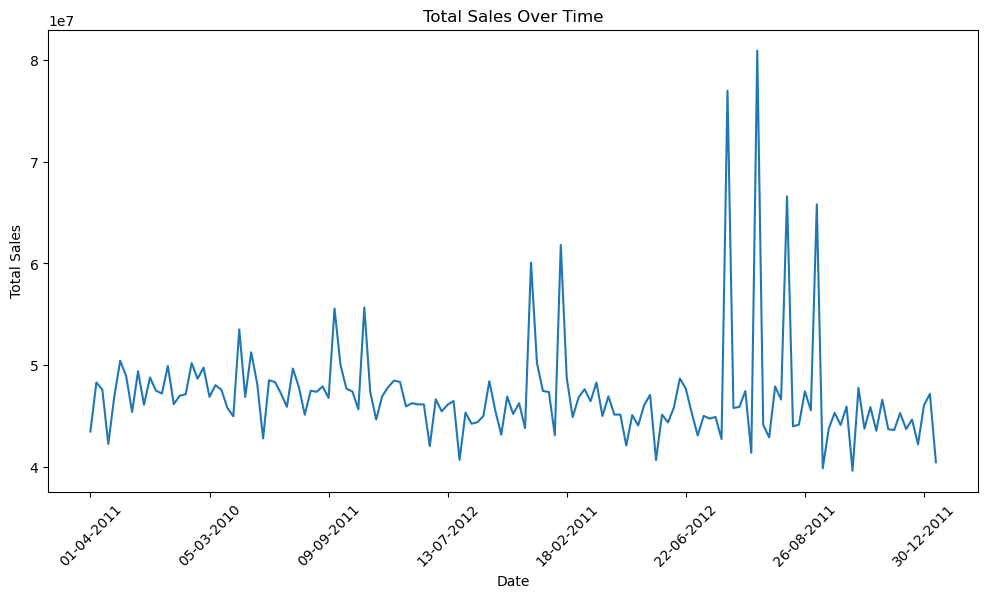

In [30]:
plt.figure(figsize=(12,6))
data.groupby('Date')['Weekly_Sales'].sum().plot(kind='line')
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

Q9: Bar Chart

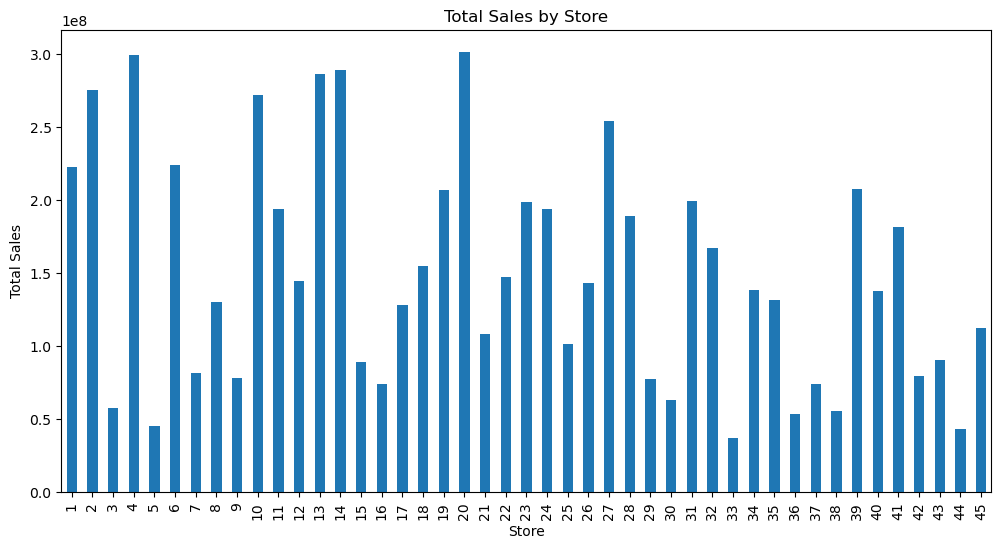

In [31]:
plt.figure(figsize=(12,6))
data.groupby('Store')['Weekly_Sales'].sum().plot(kind='bar')
plt.title('Total Sales by Store')
plt.xlabel('Store')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.show()

Q10: Pie Chart

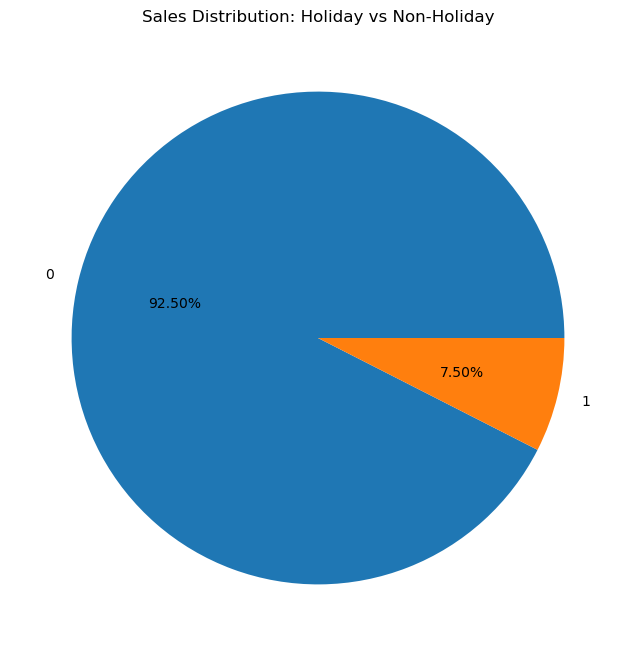

In [35]:
plt.figure(figsize=(8,8))
data.groupby('Holiday_Flag')['Weekly_Sales'].sum().plot(kind='pie', autopct='%1.2f%%')
plt.title('Sales Distribution: Holiday vs Non-Holiday')
plt.ylabel('')
plt.show()